In [3]:
import os
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import pandas as pd
import preprocessing as prep
from model import perturbation,CNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
from random import sample

# wl_path = r'D:\20240412\wl.csv'
# select_path = r'D:\20240412\0412mean.csv'

# select = pd.read_csv(select_path,header=None).values
# raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12200-2048:12200]

# mean_spec = select[1:,1:]
# mean_spec = mean_spec[12200-2048:12200,:].T.astype(float)
# mean_lab = select[0,1:].astype(float)
# SKB = SelectKBest(f_regression, k=10)
# select_feat = SKB.fit_transform(mean_spec, mean_lab.ravel())
# index_feat = SKB.get_support()
# np.savetxt(r'D:/20240412/select_wl.csv',np.vstack((raw_wl[index_feat].reshape(-1),np.where(index_feat)[0])).T,delimiter=',',fmt='%s')

path = r'D:\20240412\multi_task\all.csv'
label_path = r'D:\20240412\multi_task\alllab.csv'
wl_path = r'D:\20240412\wl.csv'
save_path = r'D:\20240412\multi_task\cnn'

# super iter
num_feat = 10
random_seed = 2024  
batch_size = 150
lr = 5e-6
num_epochs = 2000
step_epoch = 10
new_feat_size = 300
mean_times = 50
new_feat = []
new_lab = []

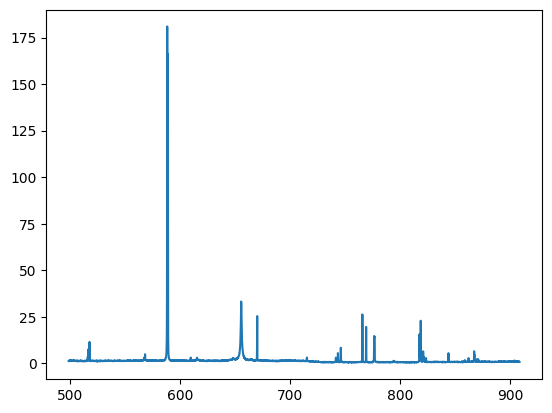

In [4]:
plt.plot(raw_wl,raw_feat[0,:])

In [ ]:
######### read raw data ####################
raw_feat = pd.read_csv(path,header=None).values.astype(np.float32)[:,12200-4096:12200]
raw_label = pd.read_csv(label_path,header=None).values.astype(np.float32)
raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12200-4096:12200]

In [5]:
######### make new feat ####################
unique_lab = np.unique(raw_label)

for labs in unique_lab:
    index = np.isin(raw_label,labs).reshape(-1)
    unique_feat = raw_feat[index,:]
    for _ in range(new_feat_size):
        new_feat.append(np.mean(unique_feat[ sample(range(0,len(unique_feat[:,0]-1)),mean_times),:],axis = 0))
        new_lab.append(labs)

new_feat = np.array(new_feat)
new_lab = np.array(new_lab).reshape(-1,1)


# 取测试集
unique_lab = np.unique(new_lab)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 3824 but corresponding boolean dimension is 7648

In [ ]:
for names in namelist:
#    wl,spec = ft.Load_MultiSpec(names)#LTB
    wl,spec = ft.read_ava(names)
    spec_num.append(len(spec[0]))
    if names == namelist[0]:
        spec1 = spec.T
    else:
        spec1 = np.vstack((spec1,spec.T))


print(namelist)
print(spec_num)

np.savetxt(path + '\\' + 'all.csv',spec1,delimiter=',',fmt='%.06f')

In [3]:

# 画图
# 导入所需的库
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# 生成预测数据
draw_day = 1825
draw_year = 2020

# tcco2等特征读取
tcco2_path_day = tcco2_path + '\\' + str(draw_day) + '_tcco2.nc'
sp_path_day = sp_path + '\\' + str(draw_day) + '_sp.nc'
d2m_path_day = d2m_path + '\\' + str(draw_day) + '_d2m.nc'
u10_path_day = u10_path + '\\' + str(draw_day) + '_u10.nc'
v10_path_day = v10_path + '\\' + str(draw_day) + '_v10.nc'

tcco2 = xr.open_dataset(tcco2_path_day).tcco2.values.astype(np.float32).reshape((-1, 1))
sp = xr.open_dataset(sp_path_day).sp.values.astype(np.float32).reshape((-1, 1))
d2m = xr.open_dataset(d2m_path_day).d2m.values.astype(np.float32).reshape((-1, 1))
u10 = xr.open_dataset(u10_path_day).u10.values.astype(np.float32).reshape((-1, 1))
v10 = xr.open_dataset(v10_path_day).v10.values.astype(np.float32).reshape((-1, 1))

for months in day_list:
    if (draw_day-months)>0:
        draw_day = draw_day-months

# 生成1801*3600的经纬度数据
lon = np.around(xr.open_dataset(tcco2_path_day).lon.values.astype(np.float32)- 180,1)#.reshape(1,-1) # 0-360转-180-180
lat = np.around(np.ceil(10 * xr.open_dataset(tcco2_path_day).lat.values.astype(np.float32))/10,1)
new_lon = np.array([lon for _ in range(len(lat))]).reshape((-1, 1))
new_lat = np.array([lat for _ in range(len(lon))]).T.reshape((-1, 1))

# 生成day,year 特征 
draw_years = np.array([(draw_year - 2000)/10 for _ in range(len(new_lon))]).reshape(-1,1)
draw_days = np.array([draw_day/360 for _ in range(len(new_lon))]).reshape(-1,1)

# 读取特征数据 
feature = np.hstack((sp, d2m, u10, v10, tcco2, new_lon, new_lat, draw_years, draw_days))
draw_feature = torch.tensor(feature, dtype=torch.float32)

feature_scaler = MinMaxScaler()
features_normalized = feature_scaler.fit_transform(draw_feature)



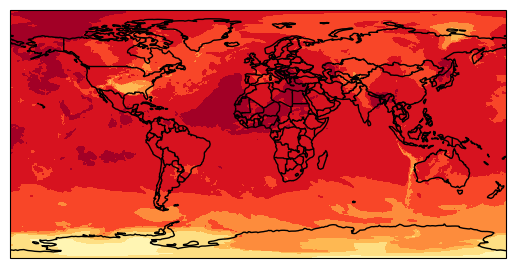

In [4]:
# 得到预测数据
# best_net.cpu()
best_net.eval()

predict_data = best_net(torch.tensor(features_normalized.astype(np.float32)).to(device))
preds_denormalized = test_label_scaler.inverse_transform(predict_data.cpu().detach().numpy())
df = pd.DataFrame({
    'Predicted': preds_denormalized.flatten(),  
})
df.to_csv('predictions.csv', index=False)

# 绘制地图
data_proj = ccrs.PlateCarree()
# ccrs

xx,yy,zz = lon,lat,preds_denormalized.reshape(1801,3600)
res = '50m'
fig = plt.figure(4)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN.with_scale(res), edgecolor='black')
ax.add_feature(cfeature.LAND.with_scale(res), edgecolor='black')
ax.add_feature(cfeature.BORDERS.with_scale(res), edgecolor='black')
ax.coastlines()
ax.contourf(xx,yy,zz,
                transform=data_proj,
                cmap='YlOrRd')
ax.set_global()
#ax.scatter(x, y, marker='o', transform=data_proj)
plt.show()